In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Setup Libraries
In this step, I imported the essential Python libraries for data handling, statistical analysis, visualization, and machine learning.

# Read Data

In [2]:
df=pd.read_csv('disease_diagnosis.csv')

Loaded the CSV file into a DataFrame to begin dataset analysis.

# Data Loading
The dataset from `disease_diagnosis.csv` was loaded into a Pandas DataFrame for medical data analysis.

# Exploratory Data Analysis (EDA)

In [3]:
df.head(10)

,Patient_ID,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Blood_Pressure_mmHg,Oxygen_Saturation_%,Diagnosis,Severity,Treatment_Plan
0,1,74,Male,Fatigue,Sore throat,Fever,69,39.4,132/91,94,Flu,Moderate,Medication and rest
1,2,66,Female,Sore throat,Fatigue,Cough,95,39.0,174/98,98,Healthy,Mild,Rest and fluids
2,3,32,Male,Body ache,Sore throat,Fatigue,77,36.8,136/60,96,Healthy,Mild,Rest and fluids
3,4,21,Female,Shortness of breath,Headache,Cough,72,38.9,147/82,99,Healthy,Mild,Rest and fluids
4,5,53,Male,Runny nose,Sore throat,Fatigue,100,36.6,109/106,92,Healthy,Mild,Rest and fluids
5,6,22,Male,Sore throat,Fever,Cough,90,39.5,107/92,93,Flu,Moderate,Medication and rest
6,7,21,Male,Sore throat,Fatigue,Cough,71,37.5,126/82,93,Bronchitis,Severe,Hospitalization and medication
7,8,71,Male,Headache,Shortness of breath,Runny nose,64,38.6,153/99,99,Healthy,Mild,Rest and fluids
8,9,56,Female,Shortness of breath,Fever,Headache,103,36.2,152/71,96,Cold,Mild,Rest and fluids
9,10,53,Male,Cough,Fever,Headache,62,39.5,111/104,98,Flu,Moderate,Medication and rest


Previewed the first 10 rows to inspect feature names and sample values.

In [4]:
df.tail()

,Patient_ID,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Blood_Pressure_mmHg,Oxygen_Saturation_%,Diagnosis,Severity,Treatment_Plan
1995,1996,23,Female,Sore throat,Runny nose,Shortness of breath,96,38.2,116/113,98,Healthy,Mild,Rest and fluids
1996,1997,75,Male,Fatigue,Cough,Sore throat,68,36.1,166/113,97,Cold,Mild,Rest and fluids
1997,1998,79,Male,Fatigue,Runny nose,Fever,73,36.7,91/103,95,Healthy,Mild,Rest and fluids
1998,1999,56,Female,Cough,Sore throat,Headache,67,39.1,128/73,91,Bronchitis,Severe,Hospitalization and medication
1999,2000,45,Female,Fatigue,Body ache,Fever,111,35.8,127/78,94,Healthy,Mild,Rest and fluids


Reviewed the last rows of the dataset to verify consistency across records.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   object 
 3   Symptom_1            2000 non-null   object 
 4   Symptom_2            2000 non-null   object 
 5   Symptom_3            2000 non-null   object 
 6   Heart_Rate_bpm       2000 non-null   int64  
 7   Body_Temperature_C   2000 non-null   float64
 8   Blood_Pressure_mmHg  2000 non-null   object 
 9   Oxygen_Saturation_%  2000 non-null   int64  
 10  Diagnosis            2000 non-null   object 
 11  Severity             2000 non-null   object 
 12  Treatment_Plan       2000 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 203.3+ KB


Used df.info() to inspect column types, row counts, and non-null entries.

# Check Missing Values

This step checks whether any columns contain missing data.

In [6]:
df.isnull().sum()
# No Found Null

Patient_ID             0
Age                    0
Gender                 0
Symptom_1              0
Symptom_2              0
Symptom_3              0
Heart_Rate_bpm         0
Body_Temperature_C     0
Blood_Pressure_mmHg    0
Oxygen_Saturation_%    0
Diagnosis              0
Severity               0
Treatment_Plan         0
dtype: int64

The result confirms that there are no missing values in the dataset.

# Inspect Columns and Categorical Features

Now we review the column names and identify categorical features that need encoding.

In [7]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3',
       'Heart_Rate_bpm', 'Body_Temperature_C', 'Blood_Pressure_mmHg',
       'Oxygen_Saturation_%', 'Diagnosis', 'Severity', 'Treatment_Plan'],
      dtype='object')

Displayed all dataset columns to identify categorical and numeric features.

In [8]:
df.drop(columns="Patient_ID",inplace=True)

Dropped the `Patient_ID` column because it is an identifier and not useful for prediction.

# Handle Duplicates

In [9]:
df.duplicated().sum()
#No Found Duplicated

np.int64(0)

# Data Preparation

In [10]:
from sklearn.preprocessing import OrdinalEncoder
encoder=OrdinalEncoder()

In [11]:
df[['Severity']]=encoder.fit_transform(df[['Severity']])

Encoded the Severity column into numeric values for model training.

In [12]:
from sklearn.preprocessing import LabelEncoder
la=LabelEncoder()

In [13]:
cols=['Gender','Treatment_Plan','Diagnosis','Symptom_3','Symptom_2','Symptom_1']
for col in cols:
    df[col]=la.fit_transform(df[col])


In [14]:
df[["blood1","blood2"]]=df['Blood_Pressure_mmHg'].str.split("/",expand=True)
df.drop(columns='Blood_Pressure_mmHg',inplace=True)

In [15]:
df['Severity_Encoded'] =encoder.fit_transform(df[['Severity']])
print(df[['Severity', 'Severity_Encoded']].head())


   Severity  Severity_Encoded
0       1.0               1.0
1       0.0               0.0
2       0.0               0.0
3       0.0               0.0
4       0.0               0.0


In [16]:
df.head()

,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Oxygen_Saturation_%,Diagnosis,Severity,Treatment_Plan,blood1,blood2,Severity_Encoded
0,74,1,2,7,3,69,39.4,94,2,1.0,1,132,91,1.0
1,66,0,7,2,1,95,39.0,98,3,0.0,2,174,98,0.0
2,32,1,0,7,2,77,36.8,96,3,0.0,2,136,60,0.0
3,21,0,6,4,1,72,38.9,99,3,0.0,2,147,82,0.0
4,53,1,5,7,2,100,36.6,92,3,0.0,2,109,106,0.0


In [17]:
cols_to_drop = ['Diagnosis', 'Treatment_Plan', 'Severity', 'Severity_Encoded'] 
x= df.drop(columns=cols_to_drop)
y = df['Severity_Encoded']


In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=40, test_size=0.2)


In [19]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)



(1600, 10)
(1600,)
(400, 10)
(400,)


In [20]:
x_train.tail()

,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Oxygen_Saturation_%,blood1,blood2
1016,69,0,1,3,2,107,39.8,99,173,92
165,35,0,1,2,3,75,37.0,94,170,90
7,71,1,4,6,5,64,38.6,99,153,99
219,68,0,2,1,0,77,36.0,95,102,100
1350,60,1,4,2,0,91,39.0,95,92,65


In [21]:
from imblearn.over_sampling import SMOTE
 
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(x_train, y_train)


In [22]:
from sklearn.tree import DecisionTreeClassifier
 
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(x_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
from sklearn import tree 

In [24]:
print('Train Set Classification Report:')
y_t_pred = model.predict(x_train)
print(classification_report(y_train, y_t_pred))
print('*********************************')
print('Test Set Classification Report:')
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

Train Set Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.97      0.90      1062
         1.0       0.83      0.54      0.65       235
         2.0       0.90      0.72      0.80       303

    accuracy                           0.86      1600
   macro avg       0.86      0.74      0.79      1600
weighted avg       0.86      0.86      0.85      1600

*********************************
Test Set Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92       268
         1.0       0.89      0.60      0.72        57
         2.0       0.89      0.79      0.84        75

    accuracy                           0.88       400
   macro avg       0.89      0.78      0.82       400
weighted avg       0.88      0.88      0.88       400



In [25]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [26]:
models={
    'svc':SVC(),
    'knn':KNeighborsClassifier(),
    'tree':DecisionTreeClassifier(),
    'rf':RandomForestClassifier()
}

In [27]:
models.keys()

dict_keys(['svc', 'knn', 'tree', 'rf'])

In [28]:
models.values()

dict_values([SVC(), KNeighborsClassifier(), DecisionTreeClassifier(), RandomForestClassifier()])

In [29]:
list(models.keys())[2]

'tree'

In [30]:
from sklearn.metrics import r2_score

In [31]:
def evaluate_model(act,pred,model_name):
    score=r2_score(act,pred)
    print(f"r2score:{score}-->{model_name}")

    return score

In [32]:
model_scores={}
for i in range(len(models)):
    model=list(models.values())[i]
    model_name=list(models.keys())[i]
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    score=evaluate_model(y_test,y_pred,model_name)
    model_scores[model_name]=score

r2score:-0.4287000630308855-->svc
r2score:-0.5687686966613645-->knn
r2score:0.8039039129173294-->tree
r2score:0.9239627417434543-->rf


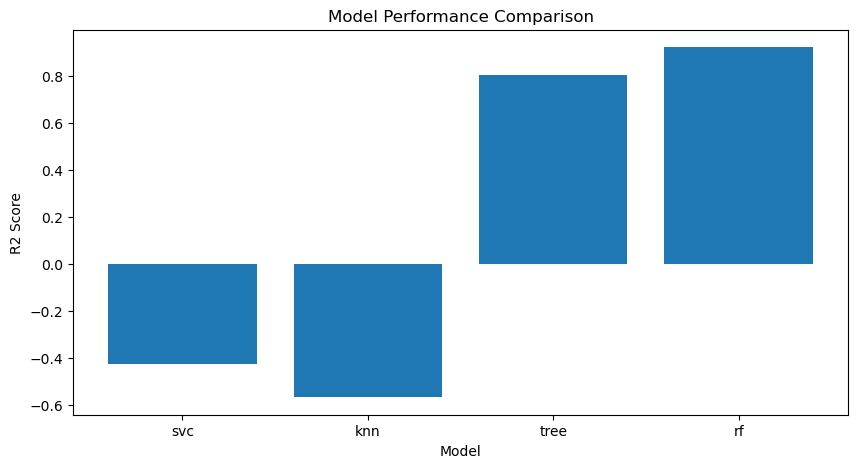

In [34]:
fig=plt.figure(figsize=(10,5))
tree_score=model_scores
plt.bar(tree_score.keys(),tree_score.values())
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.title('Model Performance Comparison')
plt.show()